# MNIST Digit Classification Training

This notebook imports the model from model.py and trains it on MNIST data


## Iteration 3: Add regularization and capacity to model, replace large size kernel with GAP in sequence and adjust max pooling location to 5*5 RF, apply transformation to train data set and play with learning rate. 

### A. Target
1. Increase the capcity of model to train it better while keeing under 10K parameters acheiveing 99.40% accuracy in less than 15 epochs. 
3. Try to make train dataset similar to test dataset, training more difficult by applying transformations to training dataset
4. Try to find the right combination of learning rates to get the required accuracy in less than 15 epochs

### B. Results
Step1 ( Increase capacity)
    1. Parameters: 9,912
    2. Best Training Accuracy in 15 epochs:99.11%
    3. Best Test Accuracy in 15 epochs:99.20%
Step2 ( Transformations)
    1. Parameters: 9,912
    2. Best Training Accuracy in 15 epochs:99.24%
    3. Best Test Accuracy in 15 epochs:99.49%
    
### C. Analysis
Step1 (Increase capacity): 
Model performs better but missing the target. We can try to push it to train better but making the training more difficult by adding random rotations to the images (-7to7) degree.
Step2 (Training dataset transformation)
We see the train accuracy is lesser than test accuracy as the training dataset is more challenging post transformations. This helps to train the model better and model acheives 99.48% in 5th epoch and consistently performs above 99.4% there onwards. Also, Adj

In [1]:
# Add model from Git Repo
!git clone https://github.com/SachinDangayach/AU_6_NN_99_4.git

fatal: destination path 'AU_6_NN_99_4' already exists and is not an empty directory.


In [2]:
# Core PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchsummary import summary
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import sys

# Add the cloned repository directory to the Python path
sys.path.append('/content/AU_6_NN_99_4')

# Import our custom model
from model_1 import Net, get_model_summary

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All imports successful!
PyTorch version: 2.8.0+cu126
CUDA available: True


In [3]:
# Device configuration
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

print(f"🖥️  Device: {device}")
if use_cuda:
    print(f"🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("💻 Using CPU")



🖥️  Device: cuda
🚀 GPU: Tesla T4
💾 GPU Memory: 15.8 GB


In [ ]:
# Data loading and preprocessing
BATCH_SIZE = 64
NUM_WORKERS = 2 if use_cuda else 0
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.RandomRotation((-7.0, 7.0), fill=(1,)),
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
])

kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': True if use_cuda else False,
    'persistent_workers': True if NUM_WORKERS > 0 else False
}

# Load datasets
train_dataset = datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **kwargs
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **kwargs
)

print(f"✅ Dataset loaded successfully!")
print(f"📚 Training samples: {len(train_dataset):,}")
print(f"🧪 Test samples: {len(test_dataset):,}")


✅ Dataset loaded successfully!
📚 Training samples: 60,000
🧪 Test samples: 10,000


## Data Exploration

[Train]
 - Numpy Shape: (60000, 28, 28)
 - Tensor Shape: torch.Size([60000, 28, 28])
 - min: tensor(0, dtype=torch.uint8)
 - max: tensor(255, dtype=torch.uint8)
 - mean: tensor(33.3184)
 - std: tensor(78.5675)
 - var: tensor(6172.8506)
 - Bin Count tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])
torch.Size([64, 1, 28, 28])
torch.Size([64])


/tmp/ipython-input-3053805808.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(labels[0])


tensor(1)

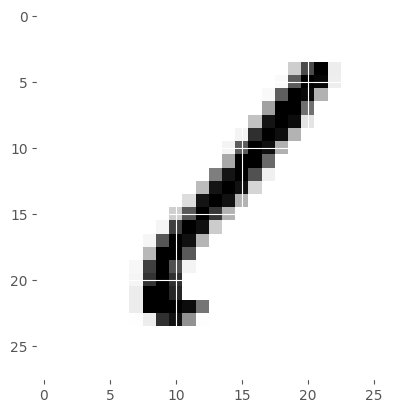

In [5]:
print('[Train]')
print(' - Numpy Shape:', train_dataset.data.cpu().numpy().shape)
print(' - Tensor Shape:', train_dataset.data.size())
print(' - min:', torch.min(train_dataset.data))
print(' - max:', torch.max(train_dataset.data))
print(' - mean:', torch.mean(train_dataset.data.float())) # Cast to float for mean/std/var
print(' - std:', torch.std(train_dataset.data.float()))   # Cast to float for mean/std/var
print(' - var:', torch.var(train_dataset.data.float()))   # Cast to float for mean/std/var
print(' - Bin Count', train_dataset.targets.bincount()) # Output shows dataset is almost balanced

dataiter = iter(train_loader)
images, labels = next(dataiter)

print(images.shape)
print(labels.shape)

# Let's visualize some of the images
plt.style.use('ggplot')

plt.imshow(images[0].numpy().squeeze(), cmap='gray_r')
torch.tensor(labels[0])

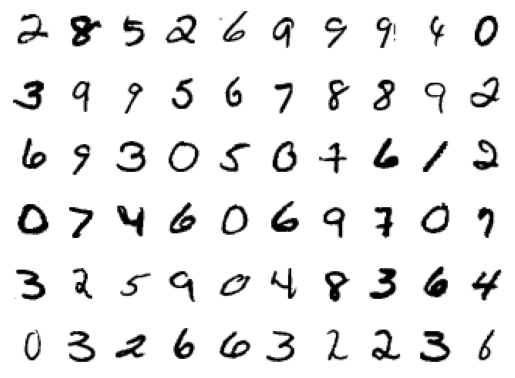

In [6]:
# Explore Data
figure = plt.figure()
num_of_images = 60
for index in range(1, num_of_images + 1):
    plt.subplot(6, 10, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

In [7]:
# Create model instance
model = Net().to(device)
print(get_model_summary())

summary(model, input_size=(1, 28, 28))


Model Summary:
- Parameters: 194,884 (trainable: 194,884)
- Input: (batch_size, 1, 28, 28)
- Output: (batch_size, 10)
- Architecture: CNN with ReLU, MaxPool2d, 1x1 convs
- Final RF: 28x28 (covers full input)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             288
              ReLU-2           [-1, 32, 26, 26]               0
            Conv2d-3           [-1, 64, 24, 24]          18,432
              ReLU-4           [-1, 64, 24, 24]               0
            Conv2d-5          [-1, 128, 22, 22]          73,728
              ReLU-6          [-1, 128, 22, 22]               0
         MaxPool2d-7          [-1, 128, 11, 11]               0
            Conv2d-8           [-1, 32, 11, 11]           4,096
              ReLU-9           [-1, 32, 11, 11]               0
           Conv2d-10             [-1, 64, 9, 9]          18,432
             ReLU-11 

In [8]:
# Training and testing functions
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct_predictions += pred.eq(target.view_as(pred)).sum().item()
        total_samples += target.size(0)

        current_acc = 100. * correct_predictions / total_samples
        pbar.set_description(
            f'Epoch {epoch} | Loss: {loss.item():.4f} | Acc: {current_acc:.2f}%'
        )

    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct_predictions / len(train_loader.dataset)
    return avg_loss, accuracy


def test(model, device, test_loader):
    model.eval()
    test_loss = 0.0
    correct_predictions = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct_predictions += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct_predictions / len(test_loader.dataset)

    print(f'\n📊 Test Results:')
    print(f'   Loss: {test_loss:.4f}')
    print(f'   Accuracy: {correct_predictions}/{len(test_loader.dataset)} ({accuracy:.2f}%)')

    return correct_predictions, test_loss, accuracy

print("✅ Training and testing functions defined!")


✅ Training and testing functions defined!


In [9]:
# Training configuration
LEARNING_RATE = 0.01
MOMENTUM = 0.9
MAX_EPOCHS = 20
TARGET_ACCURACY = 99.4
PATIENCE = 10

optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

print(f"🚀 Training Configuration:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Momentum: {MOMENTUM}")
print(f"   Max Epochs: {MAX_EPOCHS}")
print(f"   Target Accuracy: {TARGET_ACCURACY}%")

# Metrics tracking
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
epochs = []

best_accuracy = 0.0
patience_counter = 0
best_model_state = None


🚀 Training Configuration:
   Learning Rate: 0.01
   Momentum: 0.9
   Max Epochs: 20
   Target Accuracy: 99.4%


In [10]:
# Training loop
print(f"\n🎯 Starting Training...")
print("=" * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\n📈 Epoch {epoch}/{MAX_EPOCHS}")
    print("-" * 40)

    # Train the model
    train_loss, train_acc = train(model, device, train_loader, optimizer, epoch)

    # Evaluate on test set
    correct, test_loss, test_acc = test(model, device, test_loader)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    epochs.append(epoch)

    # Check for best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"🎉 New best accuracy: {best_accuracy:.2f}%")
    else:
        patience_counter += 1

    # Early stopping check
    if test_acc >= TARGET_ACCURACY:
        print(f"\n🏆 Target accuracy achieved! ({test_acc:.2f}% >= {TARGET_ACCURACY}%)")
        break

    if patience_counter >= PATIENCE and epoch > 5:
        print(f"\n⏹️  Early stopping triggered (no improvement for {PATIENCE} epochs)")
        break

print(f"\n✅ Training completed!")
print(f"📊 Final Results:")
print(f"   Best Accuracy: {best_accuracy:.2f}%")
print(f"   Total Epochs: {len(epochs)}")

# Load best model state
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"🔄 Loaded best model state (accuracy: {best_accuracy:.2f}%)")



🎯 Starting Training...

📈 Epoch 1/20
----------------------------------------


Epoch 1 | Loss: 0.1233 | Acc: 80.12%: 100%|██████████| 938/938 [00:17<00:00, 53.90it/s]



📊 Test Results:
   Loss: 0.0884
   Accuracy: 9709/10000 (97.09%)
🎉 New best accuracy: 97.09%

📈 Epoch 2/20
----------------------------------------


Epoch 2 | Loss: 0.0364 | Acc: 97.37%: 100%|██████████| 938/938 [00:15<00:00, 59.11it/s]



📊 Test Results:
   Loss: 0.0591
   Accuracy: 9812/10000 (98.12%)
🎉 New best accuracy: 98.12%

📈 Epoch 3/20
----------------------------------------


...


📊 Test Results:
   Loss: 0.0399
   Accuracy: 9892/10000 (98.92%)

📈 Epoch 19/20
----------------------------------------


Epoch 19 | Loss: 0.0002 | Acc: 99.64%: 100%|██████████| 938/938 [00:16<00:00, 58.55it/s]



📊 Test Results:
   Loss: 0.0434
   Accuracy: 9895/10000 (98.95%)

📈 Epoch 20/20
----------------------------------------


Epoch 20 | Loss: 0.0024 | Acc: 99.64%: 100%|██████████| 938/938 [00:16<00:00, 58.35it/s]



📊 Test Results:
   Loss: 0.0387
   Accuracy: 9876/10000 (98.76%)

✅ Training completed!
📊 Final Results:
   Best Accuracy: 98.95%
   Total Epochs: 20
🔄 Loaded best model state (accuracy: 98.95%)


In [15]:
# Visualization functions
def plot_training_metrics(epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Training Progress Analysis', fontsize=16, fontweight='bold')

    # Loss curves
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2.5, marker='o', markersize=4)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2.5, marker='s', markersize=4)
    ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # Accuracy curves
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2.5, marker='o', markersize=4)
    ax2.plot(epochs, test_accuracies, 'r-', label='Test Accuracy', linewidth=2.5, marker='s', markersize=4)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(95, 100)
    ax2.axhline(y=99.0, color='green', linestyle='--', alpha=0.7, label='99% Target')

    # Overfitting analysis
    loss_gap = np.array(train_losses) - np.array(test_losses)
    ax3.plot(epochs, loss_gap, 'purple', linewidth=2.5, marker='o', markersize=4)
    ax3.set_title('Overfitting Analysis (Loss Gap)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Training Loss - Test Loss')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Improvement rate
    if len(test_accuracies) > 1:
        improvement_rate = np.diff(test_accuracies)
        ax4.plot(epochs[1:], improvement_rate, 'green', linewidth=2.5, marker='o', markersize=4)
        ax4.set_title('Accuracy Improvement Rate', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy Improvement (%)')
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Training Summary:")
    print(f"   Total Epochs: {len(epochs)}")
    print(f"   Best Test Accuracy: {max(test_accuracies):.2f}%")
    print(f"   Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    print(f"   Best Test Loss: {min(test_losses):.4f}")
    print(f"   Final Test Loss: {test_losses[-1]:.4f}")


def show_predictions(model, device, test_loader, num_samples=16):
    model.eval()
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        probabilities = torch.exp(outputs)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('Model Predictions on Test Data', fontsize=16)

    for i in range(num_samples):
        row = i // 4
        col = i % 4

        img = images[i].cpu().squeeze()
        img = img * MNIST_STD + MNIST_MEAN

        true_label = labels[i].item()
        pred_label = predictions[i].item()
        confidence = probabilities[i][pred_label].item() * 100

        color = 'green' if true_label == pred_label else 'red'

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.1f}%',
                               color=color, fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    correct_predictions = (predictions[:num_samples].cpu() == labels[:num_samples]).sum().item()
    print(f"Accuracy on displayed samples: {correct_predictions}/{num_samples} ({100*correct_predictions/num_samples:.1f}%)")

print("✅ Visualization functions defined!")


✅ Visualization functions defined!


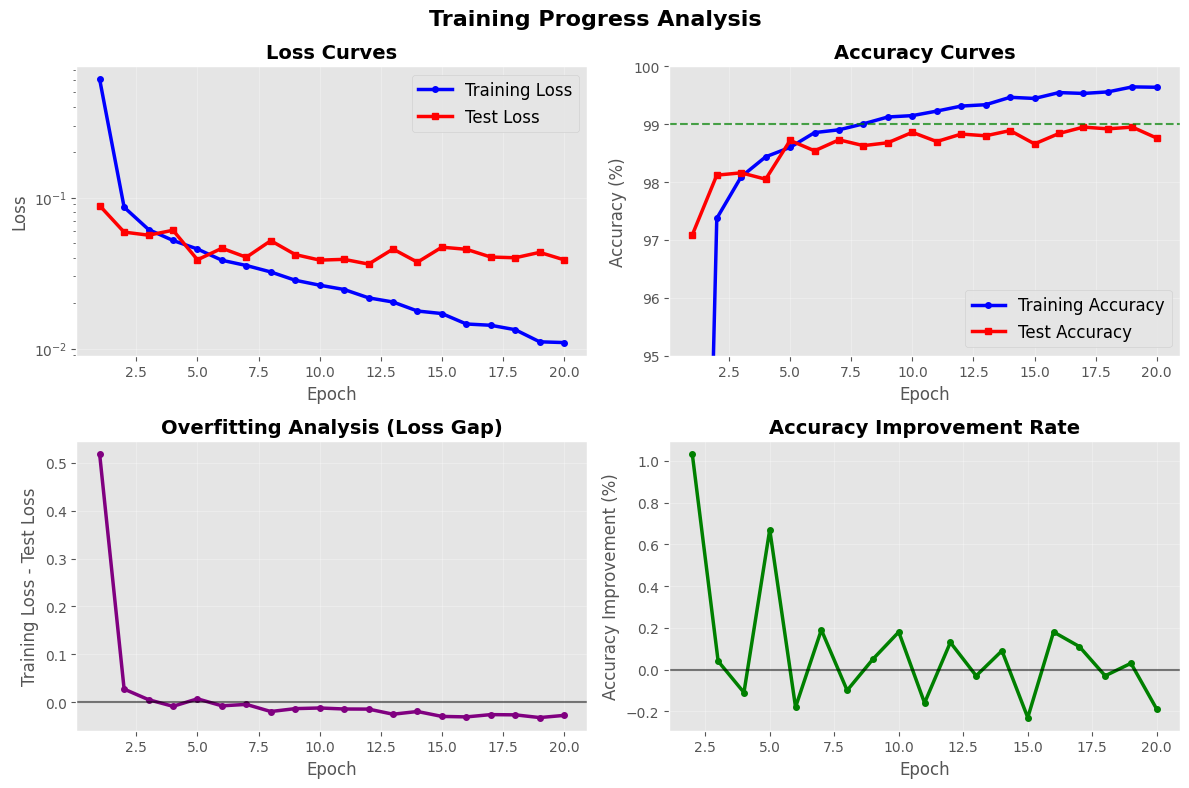


📊 Training Summary:
   Total Epochs: 20
   Best Test Accuracy: 98.95%
   Final Test Accuracy: 98.76%
   Best Test Loss: 0.0362
   Final Test Loss: 0.0387


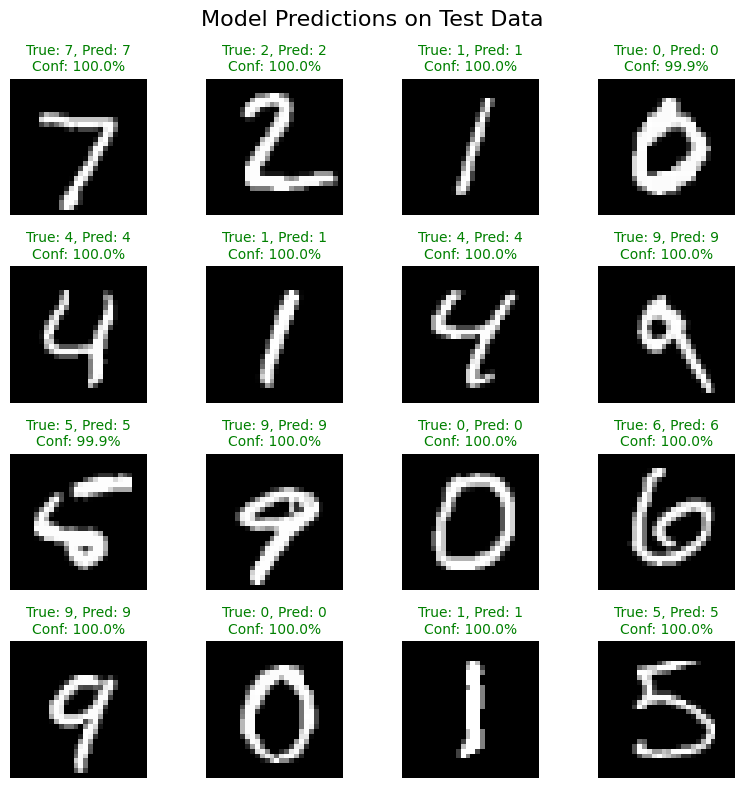

Accuracy on displayed samples: 16/16 (100.0%)


In [16]:
# Create visualizations
if len(epochs) > 0:
    plot_training_metrics(epochs, train_losses, test_losses, train_accuracies, test_accuracies)
    show_predictions(model, device, test_loader)
else:
    print("⚠️  Please run the training cell first.")
